# Лабораторная работа 2
## Визуализация данных

Вариант 2. Набор данных drivers.csv.

Выполнил: В. В. Воронов. Группа: 4311з.

Дисциплина: Введение в анализ данных. Кафедра прикладной информатики (№ 41).

Преподаватель: В. В. Боженко.

Цель работы: провести разведочный анализ набора поездок с помощью гистограмм, диаграмм размаха, диаграмм рассеивания, корреляционного анализа и дополнительных визуализаций.

Ссылка на репозиторий с ноутбуком: https://github.com/vvvl36/vad_lab_1_var_2.

## 1 Исходные данные и предварительная обработка

Набор drivers.csv содержит сведения о поездках: даты начала и окончания, категорию поездки, места отправления и назначения, расстояние в милях и цель поездки. Перед построением графиков проверяются размер таблицы, типы полей, пропуски и полные дубликаты.

Для анализа используются результаты предварительной обработки: названия полей приведены к единому виду, текстовые значения очищены, дубликаты удалены, пропуски цели поездки выделены в отдельную категорию, даты преобразованы в datetime, а длительность рассчитана в минутах. Повреждённые значения расстояния, выглядящие как серийные номера дат Excel, восстановлены по явно указанной рабочей гипотезе и сохранены также в MILES_RAW.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from common_drivers import load_raw, preprocess, save_cleaned, outlier_summary, iqr_bounds
raw = load_raw('drivers.csv')
print('Размер исходной таблицы:', raw.shape)
print('Столбцы:', list(raw.columns))
print('Типы данных:')
print(raw.dtypes.to_string())
print('Пропуски:')
print(raw.isna().sum().to_string())
print('Полные дубликаты:', int(raw.duplicated().sum()))
print('Первые 5 строк:')
print(raw.head().to_string(index=False))

Размер исходной таблицы: (161, 7)
Столбцы: ['START_DATE', 'END_DATE', 'CATEGORY*', 'START', 'STOP', 'MILES', 'PURPOSEroute']
Типы данных:
START_DATE       object
END_DATE         object
CATEGORY*        object
START            object
STOP             object
MILES           float64
PURPOSEroute     object
Пропуски:
START_DATE       0
END_DATE         0
CATEGORY*        0
START            0
STOP             0
MILES            0
PURPOSEroute    77
Полные дубликаты: 2
Первые 5 строк:
      START_DATE         END_DATE CATEGORY*   START          STOP   MILES   PURPOSEroute
01.10.2016 19:12 01.10.2016 19:32  Business Midtown   East Harlem 44963.0        MEETING
01.11.2016 13:32 01.11.2016 13:46  Business Midtown  Midtown East 45108.0 Meal/Entertain
01.12.2016 12:33 01.12.2016 12:49  Business Midtown Hudson Square 45170.0 Meal/Entertain
 1.13.2016 15:00  1.13.2016 15:28  Business Gulfton      Downtown 45149.0        Meeting
 1.29.2016 21:21  1.29.2016 21:40  Business    Apex          Cary 4505

In [2]:
df, audit = preprocess(raw)
save_cleaned(df, 'drivers_cleaned.csv')
print('После обработки:')
print('строк:', audit['clean_rows'])
print('удалено полных дублей:', audit['duplicate_count'])
print('пропусков цели, выделенных в отдельную категорию:', audit['missing_purpose'])
print('восстановлено значений MILES:', audit['recovered_miles'])
print('категории CATEGORY:', df['CATEGORY'].value_counts().to_dict())
print('категории PURPOSE:')
print(df['PURPOSE'].value_counts().to_string())
print('диапазон дат:', audit['date_min'], '—', audit['date_max'])

После обработки:
строк: 159
удалено полных дублей: 2
пропусков цели, выделенных в отдельную категорию: 77
восстановлено значений MILES: 133
категории CATEGORY: {'Business': 148, 'Personal': 11}
категории PURPOSE:
PURPOSE
Не указана        77
Meal/Entertain    34
Customer Visit    30
Meeting           13
Temporary Site     4
Moving             1
диапазон дат: 2016-01-10 19:12:00 — 2016-12-14 20:24:00


## 2 Гистограммы распределения

Построены три гистограммы: распределение расстояния MILES, длительности поездки DURATION_MIN и часа начала поездки START_HOUR. Гистограммы позволяют увидеть концентрацию наблюдений и редкие большие значения.

Построены 3 гистограммы.


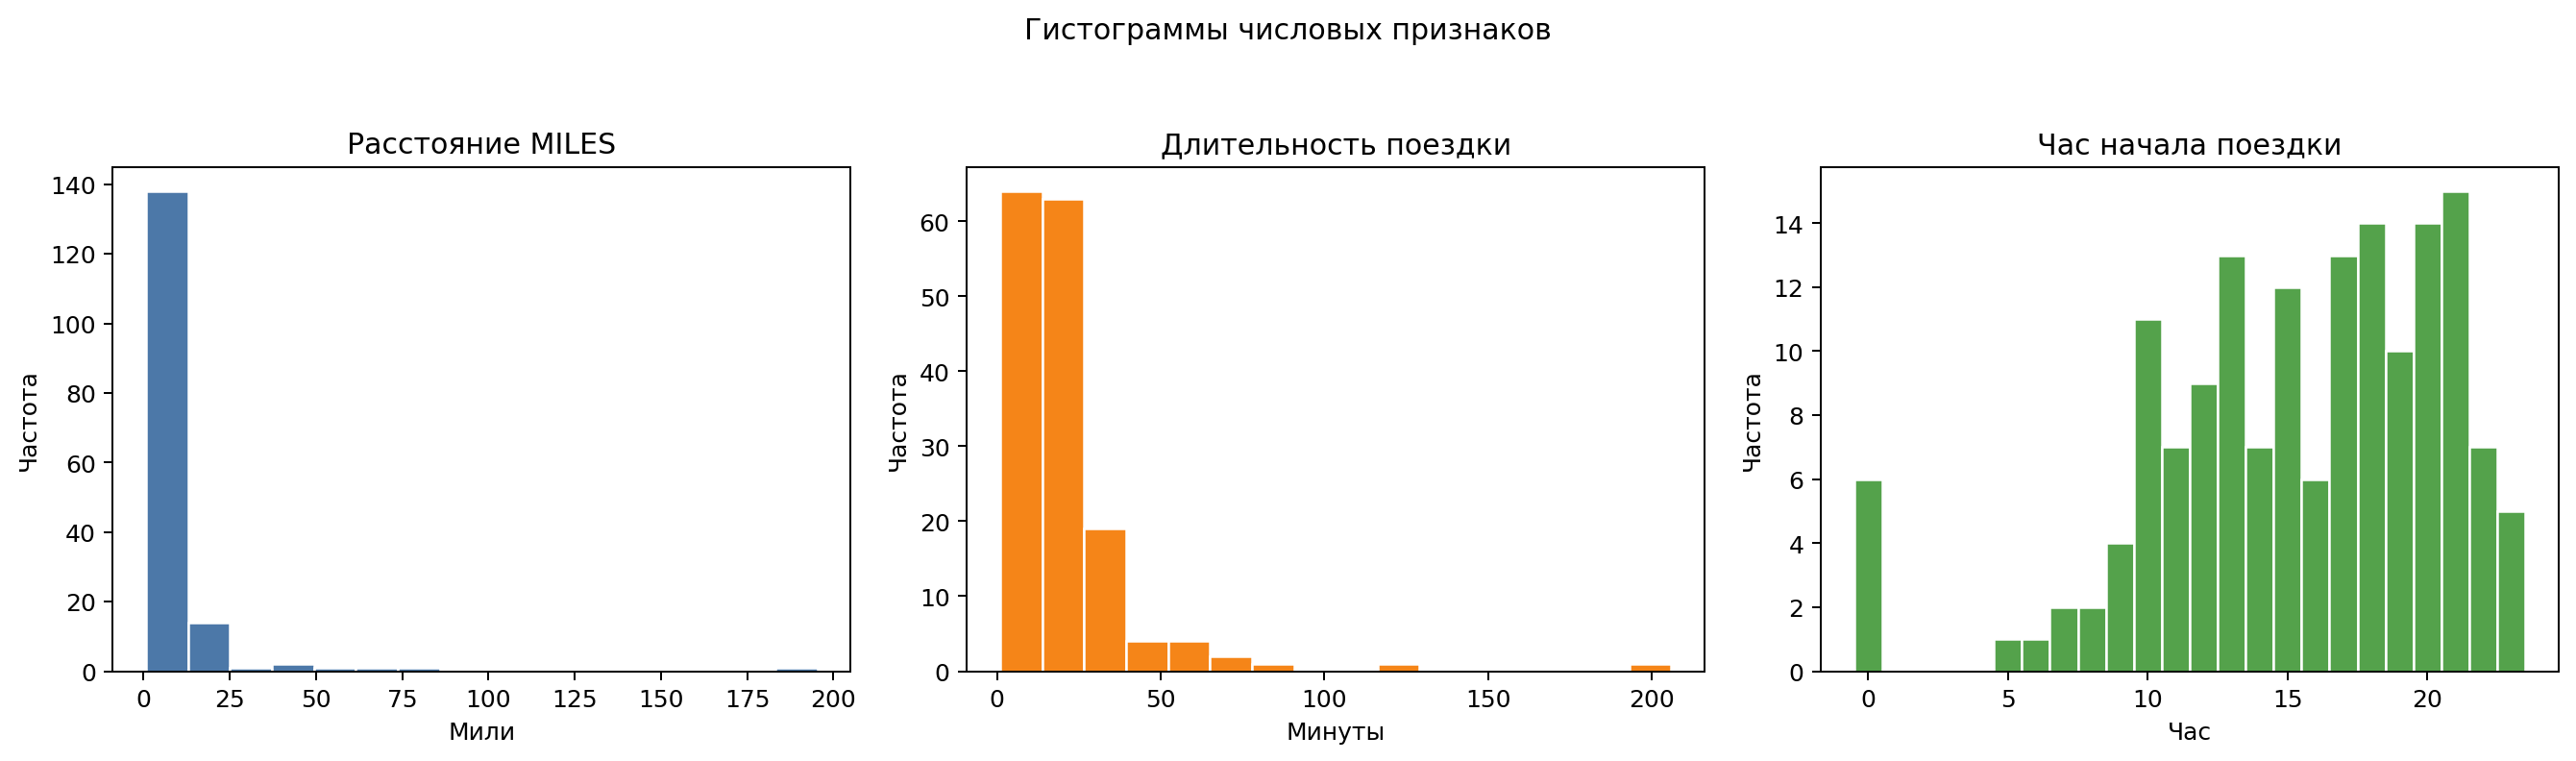

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
axes[0].hist(df['MILES'], bins=16, color='#4C78A8', edgecolor='white')
axes[0].set_title('Расстояние MILES')
axes[0].set_xlabel('Мили'); axes[0].set_ylabel('Частота')
axes[1].hist(df['DURATION_MIN'], bins=16, color='#F58518', edgecolor='white')
axes[1].set_title('Длительность поездки')
axes[1].set_xlabel('Минуты'); axes[1].set_ylabel('Частота')
axes[2].hist(df['START_HOUR'], bins=np.arange(-0.5, 24.5, 1), color='#54A24B', edgecolor='white')
axes[2].set_title('Час начала поездки')
axes[2].set_xlabel('Час'); axes[2].set_ylabel('Частота')
fig.suptitle('Гистограммы числовых признаков', y=1.04)
fig.tight_layout()
fig.savefig('figures/task2_histograms.png', dpi=180, bbox_inches='tight')
plt.close(fig)
print('Построены 3 гистограммы.')

## 3 Диаграммы размаха

Для сравнения библиотек построены две диаграммы размаха: через matplotlib и через seaborn. На них показаны расстояние и длительность поездки. Центральная линия обозначает медиану, коробка — межквартильный интервал, отдельные точки — потенциальные выбросы по правилу 1,5 IQR.

Построены boxplot в matplotlib и seaborn.


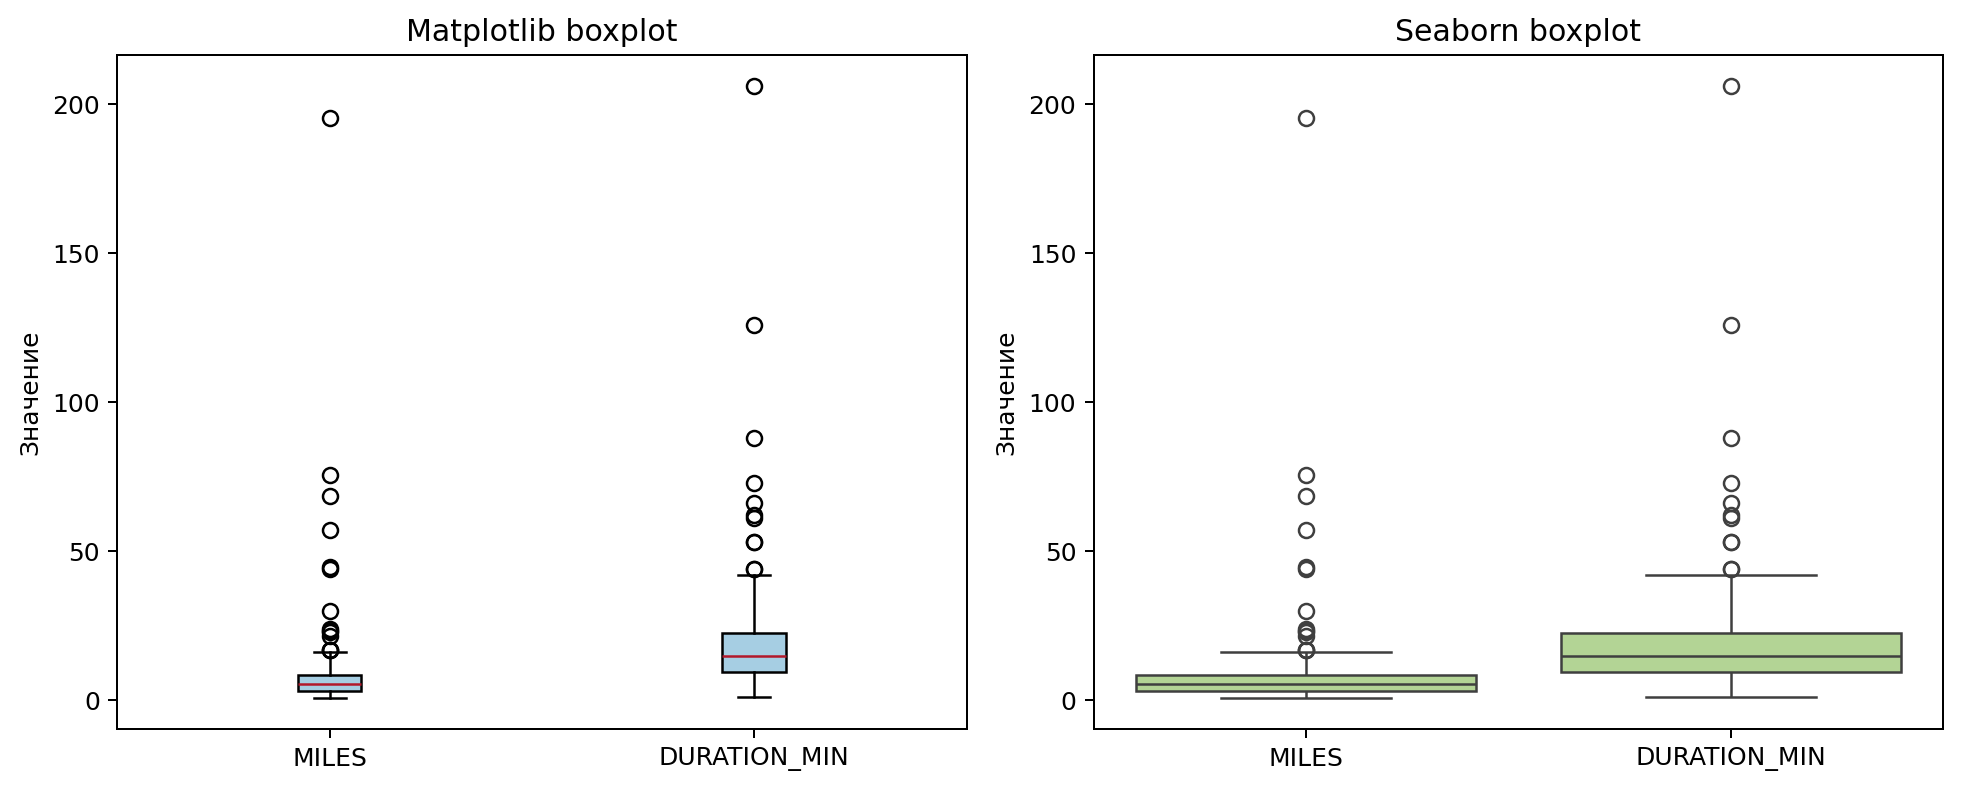

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].boxplot([df['MILES'], df['DURATION_MIN']], tick_labels=['MILES', 'DURATION_MIN'],
                patch_artist=True, boxprops={'facecolor': '#A6CEE3'},
                medianprops={'color': '#B2182B'})
axes[0].set_title('Matplotlib boxplot')
axes[0].set_ylabel('Значение')
sns.boxplot(data=df[['MILES', 'DURATION_MIN']], ax=axes[1], color='#B2DF8A')
axes[1].set_title('Seaborn boxplot')
axes[1].set_ylabel('Значение')
fig.tight_layout()
fig.savefig('figures/task3_boxplots.png', dpi=180, bbox_inches='tight')
plt.close(fig)
print('Построены boxplot в matplotlib и seaborn.')

## 4 Выбросы и повторная визуализация

Выбросы определены по правилу 1,5 IQR. В исходном очищенном наборе большие расстояния и длительные поездки не удаляются автоматически: они могут описывать реальные междугородние или длительные маршруты. Для проверки влияния экстремальных наблюдений построен отдельный визуальный вариант без строк, выходящих за границы IQR. Основной набор данных при этом сохраняется без потери наблюдений.

  Показатель  Q1    Q3  Нижняя граница  Верхняя граница  Выбросов IQR
       MILES 3.0  8.35          -5.025           16.375            14
DURATION_MIN 9.5 22.50         -10.000           42.000            11
Строк без IQR-выбросов для проверочного графика: 142
Удалено только из проверочной визуализации: 17


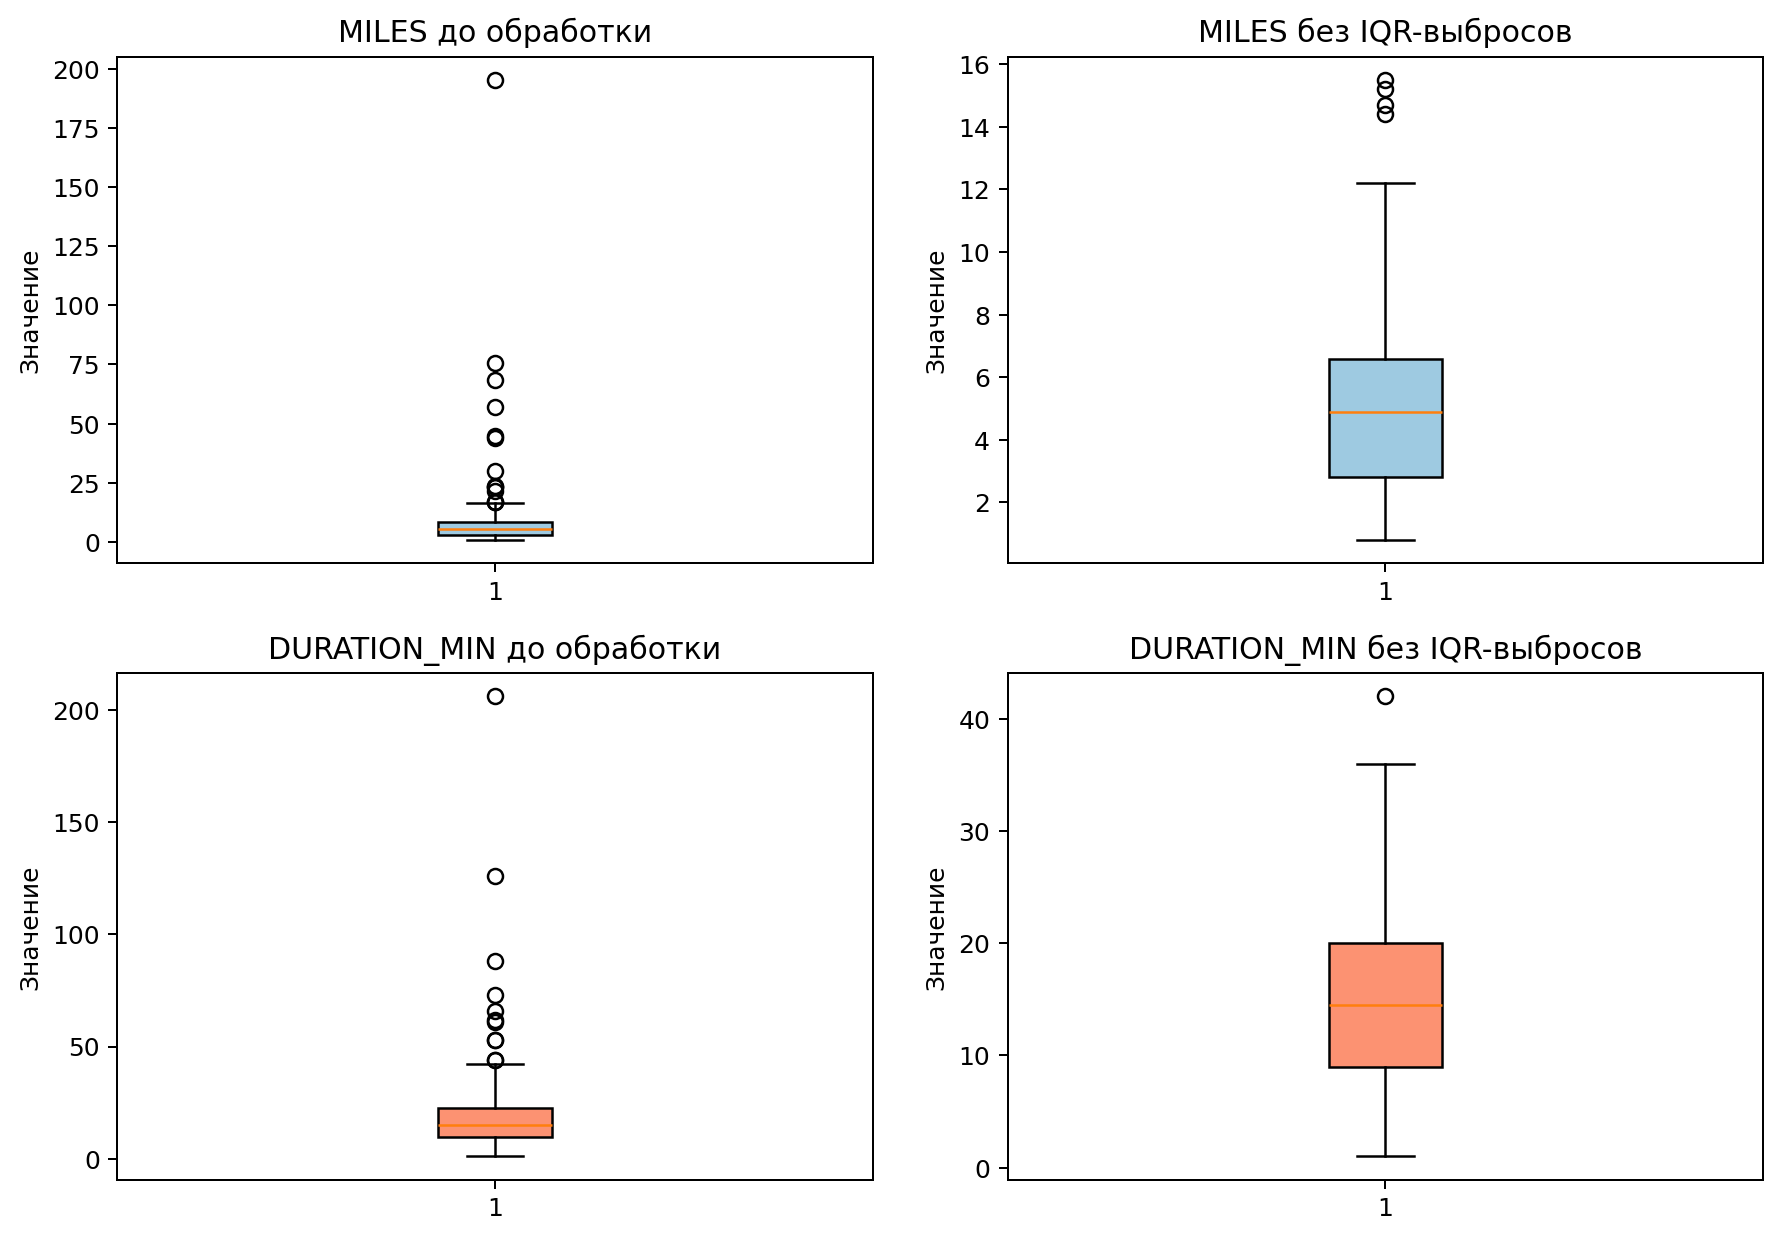

In [5]:
summary = outlier_summary(df)
summary.to_csv('results/outlier_summary.csv', sep=';', encoding='utf-8-sig', index=False)
print(summary.to_string(index=False))
q1_m, q3_m, low_m, high_m = iqr_bounds(df['MILES'])
q1_d, q3_d, low_d, high_d = iqr_bounds(df['DURATION_MIN'])
mask = (df['MILES'].lt(low_m) | df['MILES'].gt(high_m) |
        df['DURATION_MIN'].lt(low_d) | df['DURATION_MIN'].gt(high_d))
viz_df = df.loc[~mask].copy()
print('Строк без IQR-выбросов для проверочного графика:', len(viz_df))
print('Удалено только из проверочной визуализации:', int(mask.sum()))
fig, axes = plt.subplots(2, 2, figsize=(10, 7))
axes[0, 0].boxplot(df['MILES'], vert=True, patch_artist=True,
                   boxprops={'facecolor': '#9ECAE1'})
axes[0, 0].set_title('MILES до обработки')
axes[0, 1].boxplot(viz_df['MILES'], vert=True, patch_artist=True,
                   boxprops={'facecolor': '#9ECAE1'})
axes[0, 1].set_title('MILES без IQR-выбросов')
axes[1, 0].boxplot(df['DURATION_MIN'], vert=True, patch_artist=True,
                   boxprops={'facecolor': '#FC9272'})
axes[1, 0].set_title('DURATION_MIN до обработки')
axes[1, 1].boxplot(viz_df['DURATION_MIN'], vert=True, patch_artist=True,
                   boxprops={'facecolor': '#FC9272'})
axes[1, 1].set_title('DURATION_MIN без IQR-выбросов')
for ax in axes.flat:
    ax.set_ylabel('Значение')
fig.tight_layout()
fig.savefig('figures/task4_outliers.png', dpi=180, bbox_inches='tight')
plt.close(fig)

## 5 Boxplot числового признака по категориям

Чтобы сравнить распределение расстояний между категориями поездок, построен boxplot MILES по полю CATEGORY. Категория Business значительно многочисленнее Personal, поэтому различия следует трактовать с учётом размера групп.

CATEGORY  count  mean_miles  median_miles
Business    148        9.29           5.5
Personal     11        6.80           6.0


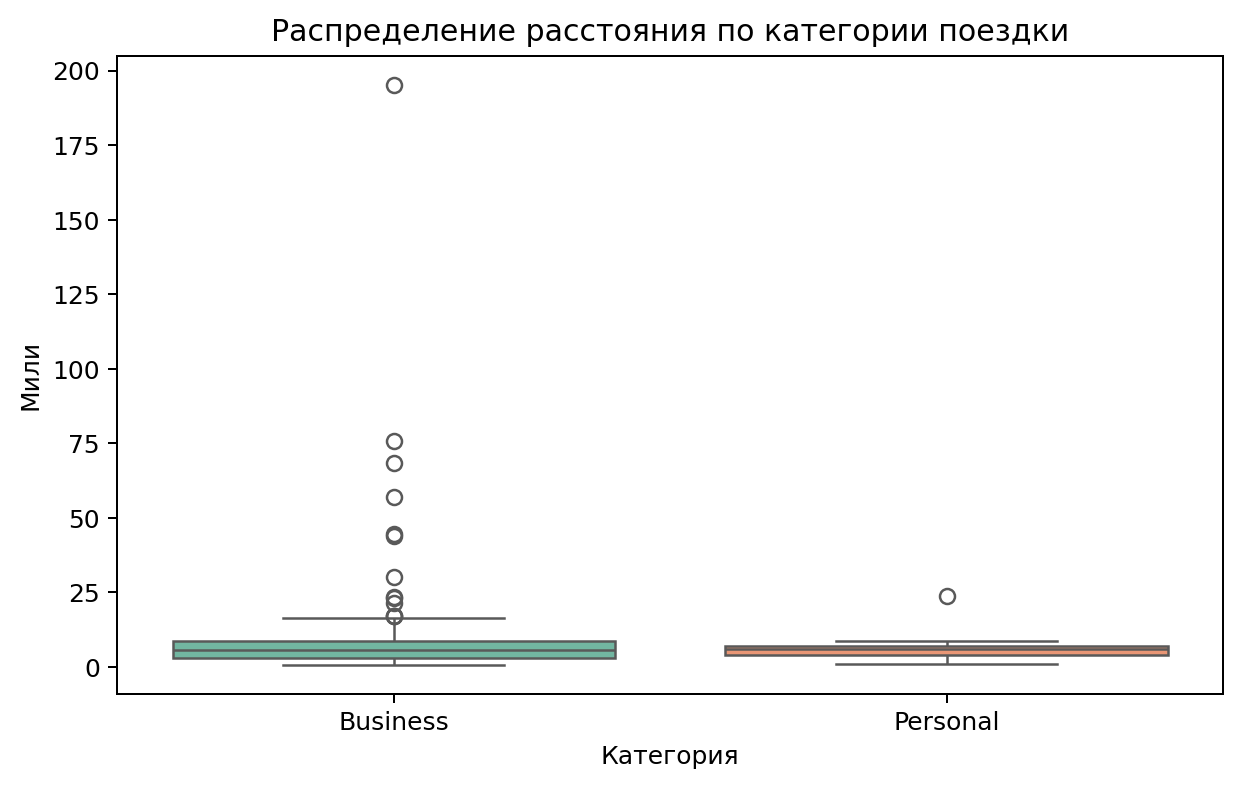

In [6]:
category_stats = df.groupby('CATEGORY', as_index=False).agg(
    count=('MILES', 'size'), mean_miles=('MILES', 'mean'),
    median_miles=('MILES', 'median')
).sort_values('mean_miles', ascending=False)
category_stats.to_csv('results/category_miles_stats.csv', sep=';', encoding='utf-8-sig', index=False)
print(category_stats.round(2).to_string(index=False))
fig, ax = plt.subplots(figsize=(7, 4.5))
sns.boxplot(data=df, x='CATEGORY', y='MILES', hue='CATEGORY',
            palette='Set2', legend=False, ax=ax)
ax.set_title('Распределение расстояния по категории поездки')
ax.set_xlabel('Категория'); ax.set_ylabel('Мили')
fig.tight_layout()
fig.savefig('figures/task5_category_boxplot.png', dpi=180, bbox_inches='tight')
plt.close(fig)

## 6 Матрица диаграмм рассеивания

Матрица диаграмм рассеивания показывает попарные зависимости между расстоянием, длительностью и часом начала поездки. Цветом выделены категории Business и Personal.

Построена матрица для признаков MILES, DURATION_MIN и START_HOUR.


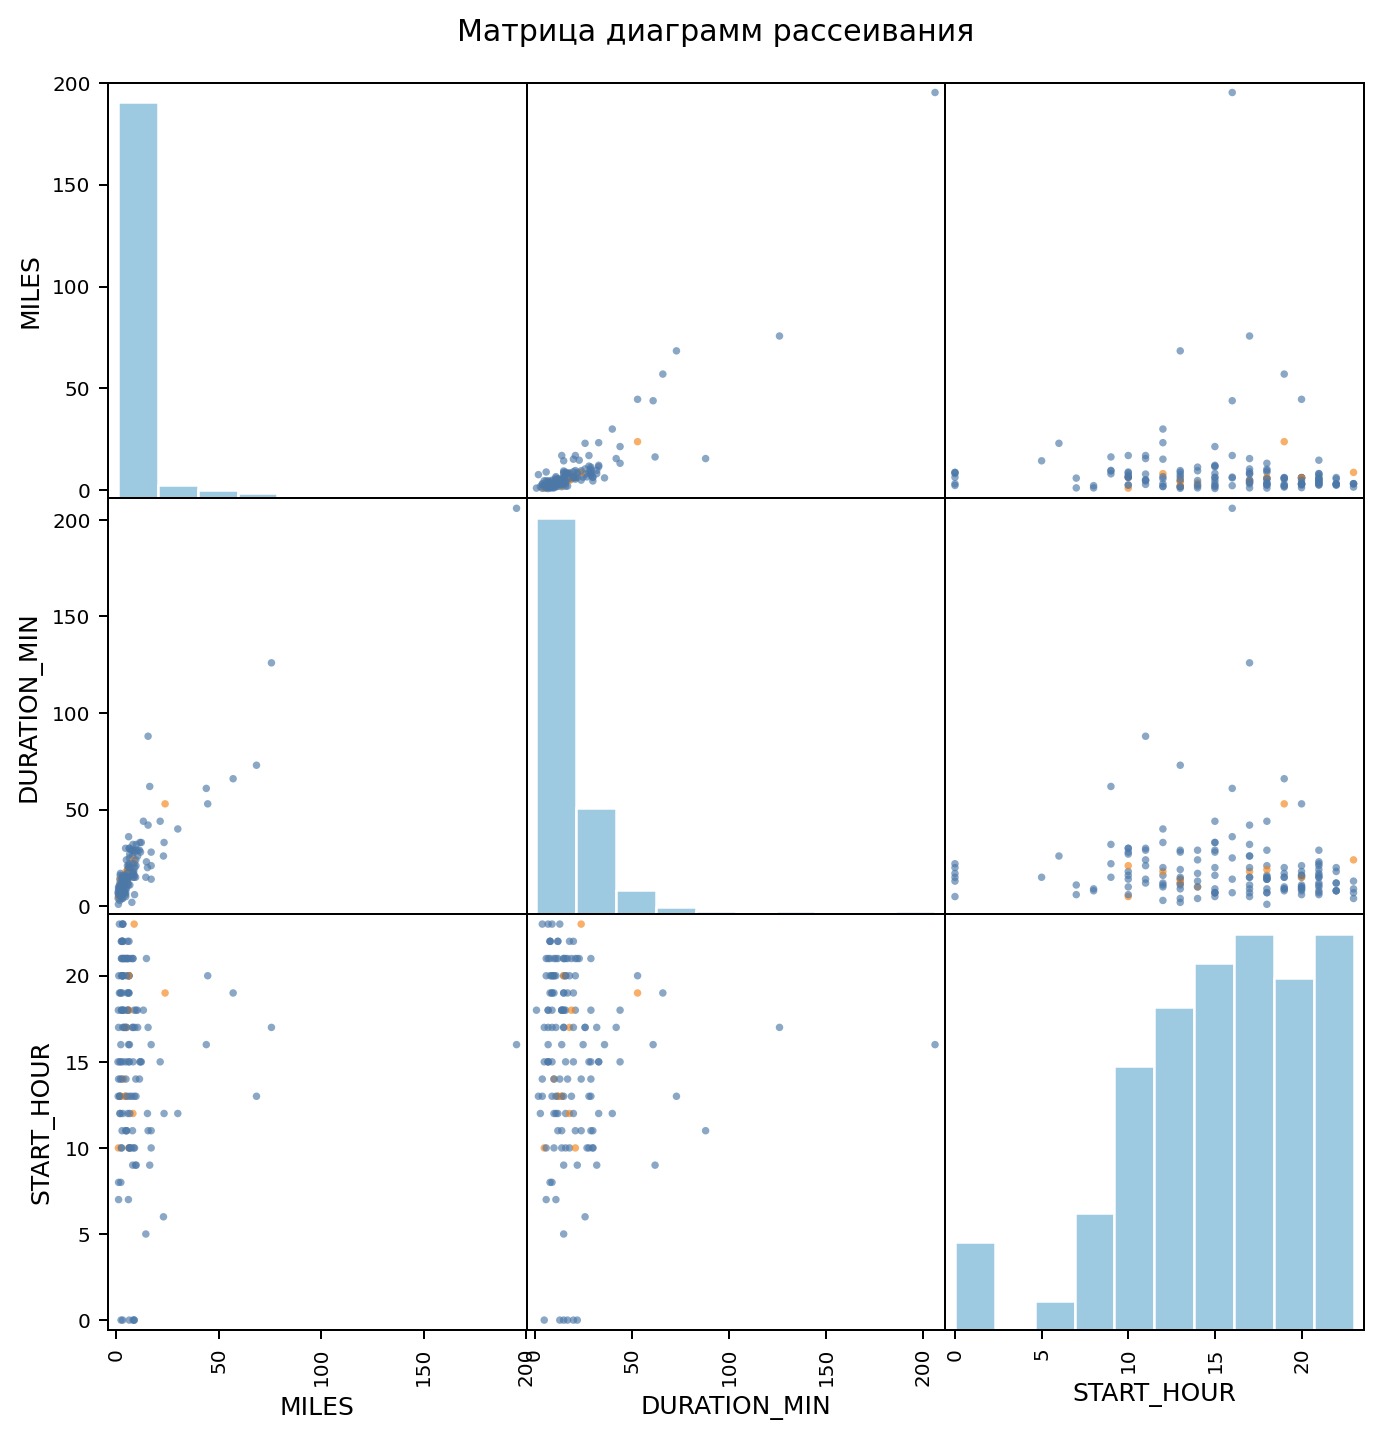

In [7]:
plot_df = df[['MILES', 'DURATION_MIN', 'START_HOUR', 'CATEGORY']].copy()
colors = plot_df['CATEGORY'].map({'Business': '#4C78A8', 'Personal': '#F58518'})
axes = pd.plotting.scatter_matrix(
    plot_df[['MILES', 'DURATION_MIN', 'START_HOUR']],
    figsize=(9, 9), diagonal='hist', alpha=0.65, color=colors,
    hist_kwds={'color': '#9ECAE1', 'edgecolor': 'white'})
plt.suptitle('Матрица диаграмм рассеивания', y=0.92)
plt.savefig('figures/task6_scatter_matrix.png', dpi=180, bbox_inches='tight')
plt.close('all')
print('Построена матрица для признаков MILES, DURATION_MIN и START_HOUR.')

## 7 Тепловая карта корреляции

Корреляция Пирсона оценивает линейную взаимосвязь числовых признаков. Для интерпретации используются расстояние, длительность, час начала и номер дня недели. Коэффициент около 1 или −1 означает сильную линейную связь, а около 0 — слабую.

              MILES  DURATION_MIN  START_HOUR  WEEKDAY_NUM
MILES         1.000         0.910      -0.021        0.076
DURATION_MIN  0.910         1.000      -0.044        0.105
START_HOUR   -0.021        -0.044       1.000       -0.042
WEEKDAY_NUM   0.076         0.105      -0.042        1.000


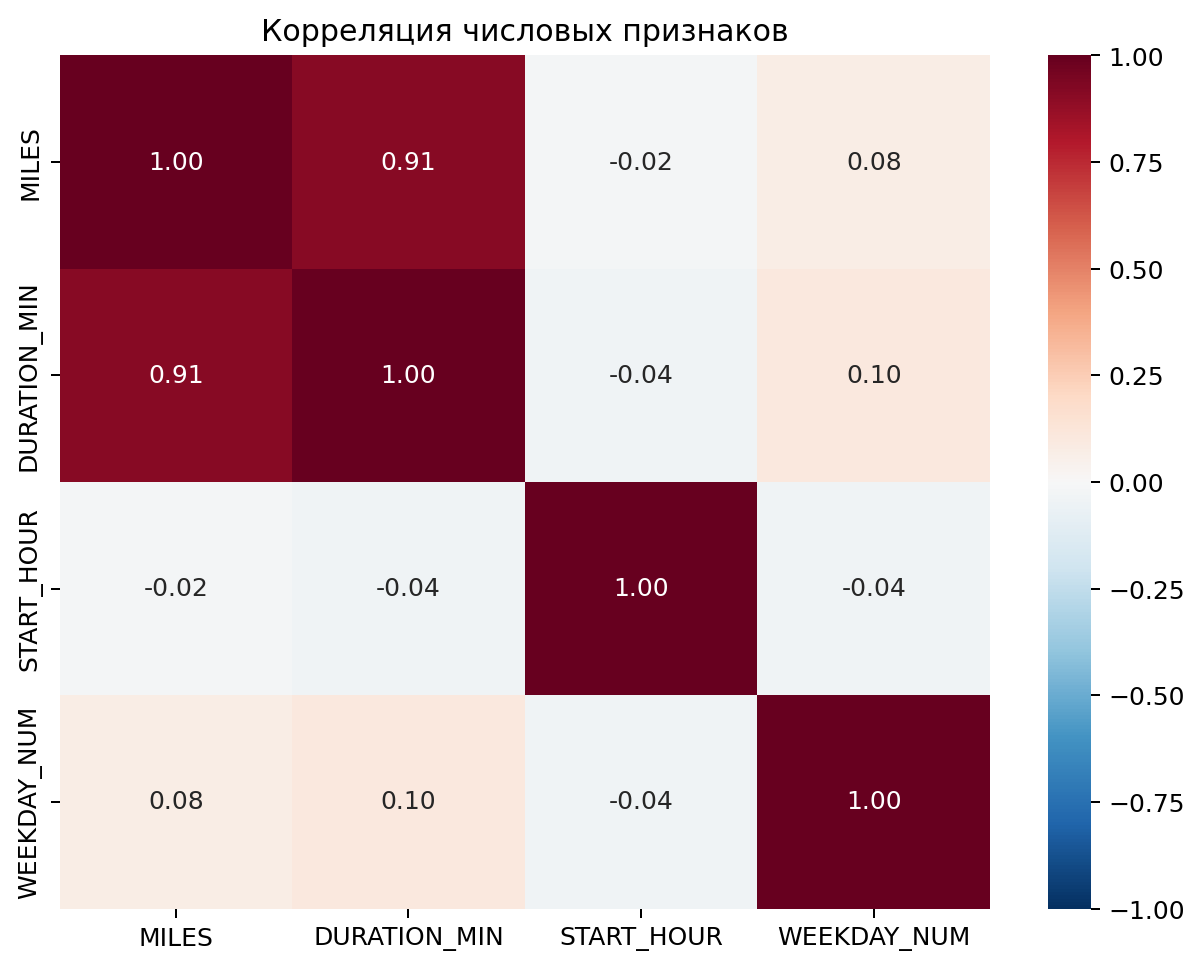

In [8]:
df['WEEKDAY_NUM'] = df['START_DATE'].dt.dayofweek
numeric = df[['MILES', 'DURATION_MIN', 'START_HOUR', 'WEEKDAY_NUM']]
corr = numeric.corr()
corr.to_csv('results/correlation.csv', sep=';', encoding='utf-8-sig')
print(corr.round(3).to_string())
fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, ax=ax)
ax.set_title('Корреляция числовых признаков')
fig.tight_layout()
fig.savefig('figures/task7_correlation_heatmap.png', dpi=180, bbox_inches='tight')
plt.close(fig)

## 8 Дополнительная визуализация

В качестве дополнительного графика выбрана горизонтальная столбчатая диаграмма количества поездок по целям. Она показывает структуру наблюдений и отдельно отражает долю поездок с неизвестной целью.

PURPOSE
Moving             1
Temporary Site     4
Meeting           13
Customer Visit    30
Meal/Entertain    34
Не указана        77


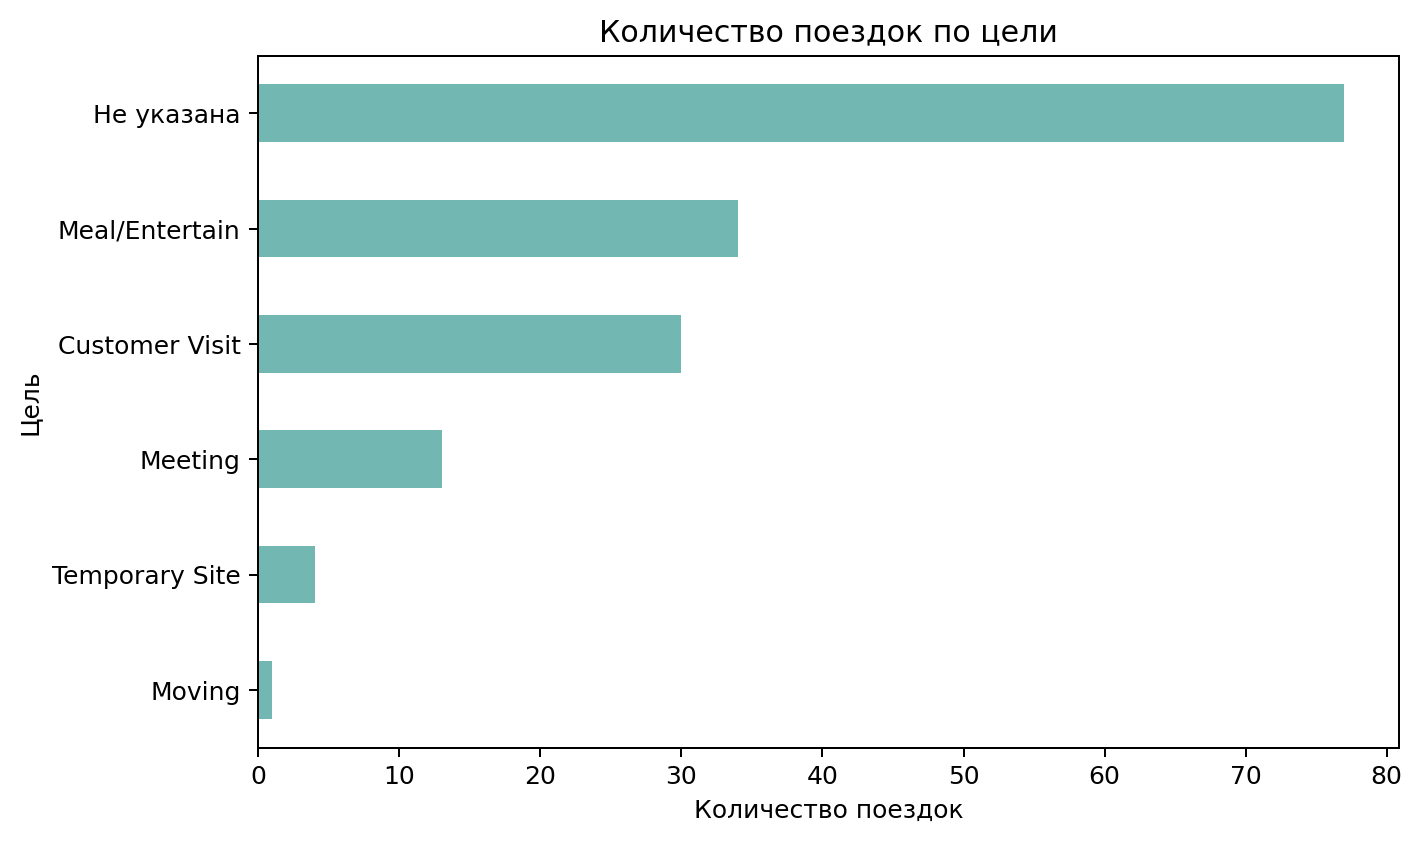

In [9]:
purpose_counts = df['PURPOSE'].value_counts().sort_values()
purpose_counts.rename_axis('PURPOSE').reset_index(name='count').to_csv(
    'results/purpose_counts.csv', sep=';', encoding='utf-8-sig', index=False)
print(purpose_counts.to_string())
fig, ax = plt.subplots(figsize=(8, 4.8))
purpose_counts.plot(kind='barh', color='#72B7B2', ax=ax)
ax.set_title('Количество поездок по цели')
ax.set_xlabel('Количество поездок'); ax.set_ylabel('Цель')
fig.tight_layout()
fig.savefig('figures/task8_purpose_bar.png', dpi=180, bbox_inches='tight')
plt.close(fig)

## 9 Вывод по работе

В работе выполнен разведочный анализ 159 поездок после удаления двух полных дубликатов. Наиболее частой категорией является Business — 148 наблюдений. В 77 строках цель поездки отсутствует, поэтому пропуск сохранён отдельной категорией «Не указана». Для 133 расстояний сохранена исходная величина и рассчитано восстановленное значение по рабочей гипотезе об ошибочном преобразовании в Excel.

Гистограммы и boxplot показали правостороннюю асимметрию распределений: большинство поездок короткие, но присутствуют редкие длительные маршруты. По правилу 1,5 IQR выявлены потенциальные выбросы расстояния и длительности; они не удалены из основного набора, поскольку могут быть реальными поездками, а исключались только из отдельной проверочной визуализации. Boxplot по категориям показывает, что Business имеет более широкий разброс расстояний, но сравнение с Personal ограничено малым размером последней группы.

Самая сильная линейная связь наблюдается между расстоянием и длительностью поездки: коэффициент корреляции составляет примерно 0,91. Это согласуется с предметной логикой маршрута: более длинные поездки обычно занимают больше времени. Связь с часом начала и днём недели слабая. Столбчатая диаграмма подтверждает преобладание поездок с неизвестной целью и деловых поездок с целями Meal/Entertain и Customer Visit.

## 10 Использованные материалы

1. Лабораторная работа 2 «Визуализация данных»: требования к EDA и составу отчёта.
2. Контрольная работа «Предварительный анализ данных»: требования к обработке CSV, пропускам, дубликатам и типам данных.
3. Лабораторная работа 1 «Методы агрегации и группировки данных»: вариант 2 и описание drivers.csv.
4. В. В. Боженко, Т. М. Татарникова. Язык программирования Python для анализа данных. СПб.: ГУАП, 2023.
5. Предоставленный файл drivers.csv.